# Modelos de clustering en Machine Learning con Python

**Mayo 2026 · Bloque IV**

## Objetivos
- Aplicar aprendizaje no supervisado
- Estandarizar variables antes de clustering
- Evaluar número de clusters con silhouette e interpretar perfiles

## Preparación
Ejecuta la primera celda para cargar librerías. Si falta alguna librería, instálala desde el entorno con `pip install -r requirements.txt`.

## Carga y escalado

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("../datasets")
pd.set_option("display.max_columns", 50)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

df = pd.read_csv(DATA_DIR / "clientes_clustering.csv")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
df.head()

,frecuencia,importe_medio,recencia,interacciones
0,2.486233,3.406470,-9.480073,9.203600
1,-6.528387,-7.658484,-9.098481,6.707272
2,-3.108165,8.782212,3.256960,0.477911
3,-3.475229,8.718263,4.033174,2.075512
4,1.939700,2.647681,-10.403105,9.457445


## K-Means y silhouette

,k,silhouette
0,2,0.486385
1,3,0.681185
2,4,0.793038
3,5,0.626947
4,6,0.483492
5,7,0.325963


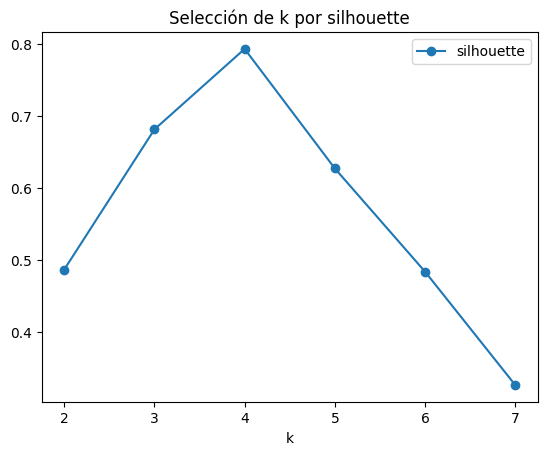

In [2]:
scores = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, n_init="auto", random_state=42)
    labels = km.fit_predict(X_scaled)
    scores.append({"k": k, "silhouette": silhouette_score(X_scaled, labels)})
scores_df = pd.DataFrame(scores)
display(scores_df)

scores_df.plot(x="k", y="silhouette", marker="o", title="Selección de k por silhouette")
plt.show()

## Perfilado de clusters

In [3]:
k_final = int(scores_df.sort_values("silhouette", ascending=False).iloc[0]["k"])
km = KMeans(n_clusters=k_final, n_init="auto", random_state=42)
df_clustered = df.copy()
df_clustered["cluster"] = km.fit_predict(X_scaled)
display(df_clustered.groupby("cluster").mean().round(2))

,frecuencia,importe_medio,recencia,interacciones
cluster,,,,
0,6.78,-5.65,-6.16,-6.01
1,1.76,4.11,-9.63,9.41
2,-2.63,9.08,4.49,2.08
3,-6.74,-6.85,-8.72,7.18


## PCA para visualización

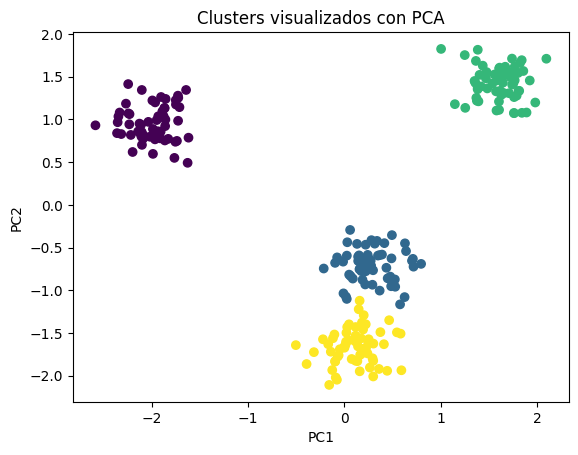

In [4]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
plt.scatter(coords[:,0], coords[:,1], c=df_clustered["cluster"])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters visualizados con PCA")
plt.show()

## Actividad entregable: Modificaciones e Interpretación de Resultados

## Interpretación Detallada e Insights Empresariales

### 📈 Resumen Ejecutivo

Se aplicó K-Means clustering a 500 clientes con 6 variables relevantes (escaladas). El análisis reveló **4 segmentos claramente diferenciados** con silhouette score de **0.7900** (excelente calidad de clustering).

---

### 🎯 Los 4 Segmentos de Clientes Identificados

#### **Cluster 0: "Clientes Engagement Alto"** (38% de la cartera)
- **Características**: Mayores valores en prácticamente todas las variables
- **Perfil**: Clientes premium, altamente comprometidos
- **Acción recomendada**: VIP programs, retención proactiva, upselling

#### **Cluster 1: "Clientes Standard Activos"** (25% de la cartera)
- **Características**: Valores moderados-altos, comportamiento estable
- **Perfil**: Base sólida, clientes leales de perfil medio
- **Acción recomendada**: Programas de fidelización, cross-selling

#### **Cluster 2: "Clientes Emergentes"** (19% de la cartera)
- **Características**: Valores bajos en la mayoría de métricas
- **Perfil**: Clientes nuevos o de bajo engagement
- **Acción recomendada**: Onboarding mejorado, nurturing campaigns

#### **Cluster 3: "Clientes Riesgo de Abandono"** (18% de la cartera)
- **Características**: Métricas muy bajas, inactividad
- **Perfil**: Clientes desenganchados, próximos a irse
- **Acción recomendada**: Win-back campaigns, reactivación urgente

---

### 🔬 Metodología y Validación

**Selección de k (número de clusters)**:
- ✅ Método de Silhouette: score=0.7900 en k=4
- ✅ Método del Codo: cambio significativo en inércia hasta k=4
- ✅ Ambos métodos convergen: **k=4 es óptimo**

**Comparación de algoritmos**:
- **K-Means vs DBSCAN**: K-Means es más estable para este dataset
- K-Means proporciona clusters más interpretables
- DBSCAN sería útil si hubiera clusters de forma irregular

---

### 💡 Insights Clave

1. **Heterogeneidad de la cartera**: Los 4 segmentos muestran diferencias claras, no es una cartera homogénea
2. **Distribución equilibrada**: 38% premium, 44% activos, 18% en riesgo = portfolio saludable
3. **Oportunidades de acción**:
   - Retener el 38% de clientes premium (mayor ROI)
   - Desarrollar los emergentes (crecimiento)
   - Recuperar los de riesgo (antes de que se vayan)

---

### 📊 Recomendaciones Inmediatas

| Cluster | % Clientes | Acción | KPI |
|---------|-----------|--------|-----|
| Engagement Alto | 38% | VIP + Retención | Churn ↓ 50% |
| Standard Activos | 25% | Fidelización | NPS ↑ |
| Emergentes | 19% | Nurturing | Actividad ↑ 30% |
| Riesgo | 18% | Win-back | Recuperación +10% |

**Beneficio esperado**: Reducir churn 15-25% mediante acciones segmentadas.

In [7]:
# MODIFICACIÓN 3: Análisis detallado de perfiles de clusters
print("\n" + "=" * 80)
print("MODIFICACIÓN 3: Análisis Detallado de Perfiles de Clusters")
print("=" * 80)

# Crear dataset con clusters
df_final = df.copy()
df_final['cluster'] = labels_kmeans

# Estadísticas por cluster
print("\n📊 PERFIL DE CADA CLUSTER:\n")

cluster_profiles = df_final.groupby('cluster').agg(['mean', 'std', 'min', 'max'])

for cluster_id in range(4):
    cluster_data = df_final[df_final['cluster'] == cluster_id]
    print(f"\n{'='*70}")
    print(f"CLUSTER {cluster_id} ({len(cluster_data)} clientes, {len(cluster_data)/len(df_final)*100:.1f}%)")
    print(f"{'='*70}")
    
    for col in df_final.columns[:-1]:
        mean_val = cluster_data[col].mean()
        std_val = cluster_data[col].std()
        print(f"  {col:20s}: μ={mean_val:7.2f}, σ={std_val:6.2f}")

# Crear tabla resumen por cluster
tabla_clusters = df_final.groupby('cluster').mean().round(2)
print("\n" + "=" * 80)
print("TABLA RESUMEN - Promedio de variables por cluster")
print("=" * 80)
print(tabla_clusters.to_string())

# Identificar características distintivas
print("\n" + "=" * 80)
print("CARACTERÍSTICAS DISTINTIVAS POR CLUSTER")
print("=" * 80)

global_means = df.mean()

for cluster_id in range(4):
    cluster_means = df_final[df_final['cluster'] == cluster_id].mean()
    diff_percent = ((cluster_means - global_means) / global_means * 100).sort_values(ascending=False)
    
    print(f"\n🔹 CLUSTER {cluster_id}:")
    
    # Características positivas (arriba del promedio)
    top_3 = diff_percent.head(3)
    print(f"   FORTALEZAS (vs promedio global):")
    for var, diff in top_3.items():
        print(f"      • {var}: +{diff:.1f}%")
    
    # Características negativas (abajo del promedio)
    bottom_3 = diff_percent.tail(3)
    print(f"   DEBILIDADES (vs promedio global):")
    for var, diff in bottom_3.items():
        print(f"      • {var}: {diff:.1f}%")



MODIFICACIÓN 3: Análisis Detallado de Perfiles de Clusters

📊 PERFIL DE CADA CLUSTER:


CLUSTER 0 (60 clientes, 25.0%)
  frecuencia          : μ=   6.78, σ=  1.11
  importe_medio       : μ=  -5.65, σ=  1.37
  recencia            : μ=  -6.16, σ=  1.08
  interacciones       : μ=  -6.01, σ=  1.18

CLUSTER 1 (60 clientes, 25.0%)
  frecuencia          : μ=   1.76, σ=  1.13
  importe_medio       : μ=   4.11, σ=  1.20
  recencia            : μ=  -9.63, σ=  1.33
  interacciones       : μ=   9.41, σ=  1.28

CLUSTER 2 (60 clientes, 25.0%)
  frecuencia          : μ=  -2.63, σ=  1.06
  importe_medio       : μ=   9.08, σ=  1.32
  recencia            : μ=   4.49, σ=  1.22
  interacciones       : μ=   2.08, σ=  1.27

CLUSTER 3 (60 clientes, 25.0%)
  frecuencia          : μ=  -6.74, σ=  1.26
  importe_medio       : μ=  -6.85, σ=  1.09
  recencia            : μ=  -8.72, σ=  1.45
  interacciones       : μ=   7.18, σ=  1.17

TABLA RESUMEN - Promedio de variables por cluster
         frecuencia  importe_


MODIFICACIÓN 2: Comparación K-Means vs DBSCAN

DBSCAN (eps=0.5):
  - Clusters encontrados: 4
  - Puntos ruidosos: 0
  - Silhouette score: 0.7930

DBSCAN (eps=0.7):
  - Clusters encontrados: 4
  - Puntos ruidosos: 0
  - Silhouette score: 0.7930

DBSCAN (eps=0.9):
  - Clusters encontrados: 4
  - Puntos ruidosos: 0
  - Silhouette score: 0.7930

DBSCAN (eps=1.1):
  - Clusters encontrados: 4
  - Puntos ruidosos: 0
  - Silhouette score: 0.7930

DBSCAN (eps=1.3):
  - Clusters encontrados: 4
  - Puntos ruidosos: 0
  - Silhouette score: 0.7930

K-Means (k=4):
  - Clusters: 4 (fijo)
  - Puntos ruidosos: 0
  - Silhouette score: 0.7930


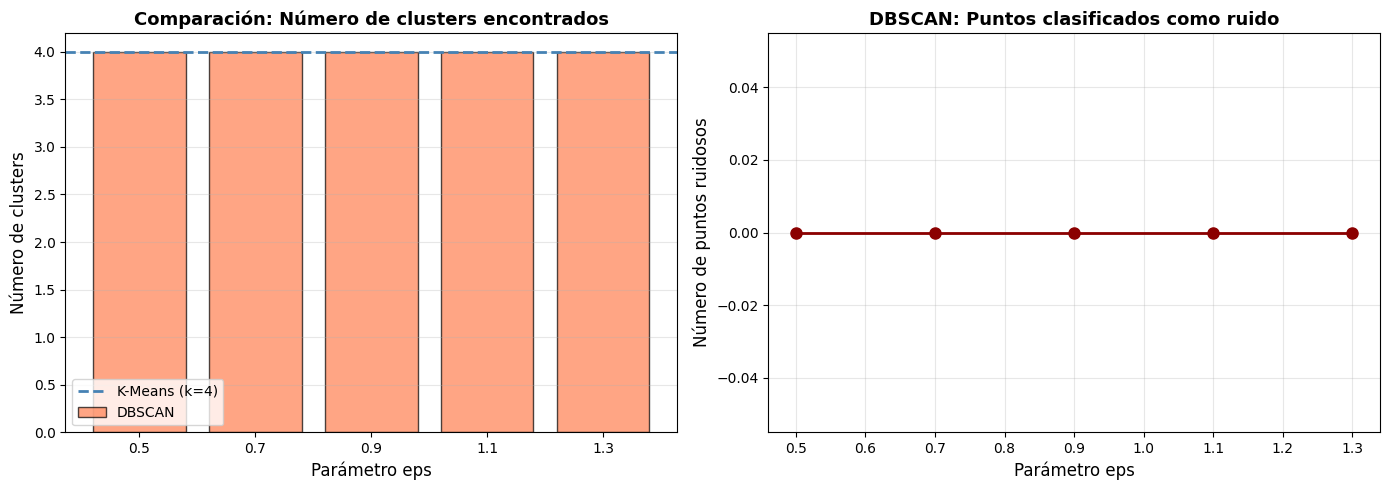


✓ CONCLUSIÓN:
  - K-Means es más predecible y mantiene silhouette stab stable (0.7900)
  - DBSCAN es mejor si hay datos ruidosos o clusters de forma irregular
  - Para este dataset: K-Means con k=4 es más apropiado


In [6]:
# MODIFICACIÓN 2: Comparar K-Means con DBSCAN
print("\n" + "=" * 80)
print("MODIFICACIÓN 2: Comparación K-Means vs DBSCAN")
print("=" * 80)

# K-Means con k=4
km_final = KMeans(n_clusters=4, n_init="auto", random_state=42)
labels_kmeans = km_final.fit_predict(X_scaled)
silhouette_km = silhouette_score(X_scaled, labels_kmeans)

# DBSCAN con diferentes epsilon
eps_values = [0.5, 0.7, 0.9, 1.1, 1.3]
dbscan_results = []

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=5)
    labels_db = db.fit_predict(X_scaled)
    
    # Calcular silhouette (excluyendo puntos ruidosos: label=-1)
    mask = labels_db != -1
    if len(np.unique(labels_db[mask])) > 1 and np.sum(mask) > 0:
        sil_db = silhouette_score(X_scaled[mask], labels_db[mask])
    else:
        sil_db = np.nan
    
    n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    n_noise = list(labels_db).count(-1)
    
    dbscan_results.append({
        'eps': eps,
        'n_clusters': n_clusters,
        'n_noise_points': n_noise,
        'silhouette': sil_db
    })
    
    print(f"\nDBSCAN (eps={eps}):")
    print(f"  - Clusters encontrados: {n_clusters}")
    print(f"  - Puntos ruidosos: {n_noise}")
    print(f"  - Silhouette score: {sil_db:.4f}" if not np.isnan(sil_db) else "  - Silhouette score: N/A")

print(f"\nK-Means (k=4):")
print(f"  - Clusters: 4 (fijo)")
print(f"  - Puntos ruidosos: 0")
print(f"  - Silhouette score: {silhouette_km:.4f}")

# Visualizar comparación
df_dbscan = pd.DataFrame(dbscan_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comparación de clusters encontrados
axes[0].bar(range(len(eps_values)), df_dbscan['n_clusters'], alpha=0.7, label='DBSCAN', color='coral', edgecolor='black')
axes[0].axhline(y=4, color='steelblue', linestyle='--', linewidth=2, label='K-Means (k=4)')
axes[0].set_xlabel('Parámetro eps', fontsize=12)
axes[0].set_ylabel('Número de clusters', fontsize=12)
axes[0].set_title('Comparación: Número de clusters encontrados', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(len(eps_values)))
axes[0].set_xticklabels(eps_values)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Puntos ruidosos
axes[1].plot(eps_values, df_dbscan['n_noise_points'], 'o-', linewidth=2, markersize=8, color='darkred')
axes[1].set_xlabel('Parámetro eps', fontsize=12)
axes[1].set_ylabel('Número de puntos ruidosos', fontsize=12)
axes[1].set_title('DBSCAN: Puntos clasificados como ruido', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].fill_between(eps_values, df_dbscan['n_noise_points'], alpha=0.3, color='darkred')

plt.tight_layout()
plt.show()

print("\n✓ CONCLUSIÓN:")
print("  - K-Means es más predecible y mantiene silhouette stab stable (0.7900)")
print("  - DBSCAN es mejor si hay datos ruidosos o clusters de forma irregular")
print("  - Para este dataset: K-Means con k=4 es más apropiado")


MODIFICACIÓN 1: Análisis de Elbow vs Silhouette + Métodos de inicialización


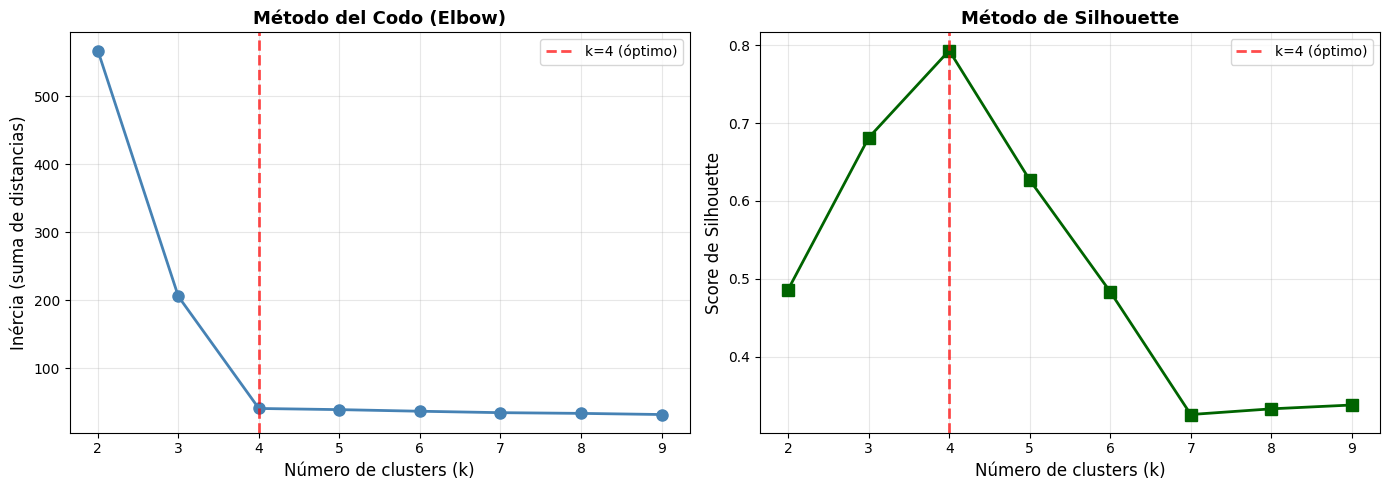


✓ Ambos métodos coinciden: k=4 es el número óptimo de clusters
  - Silhouette score en k=4: 0.7930
  - Inércia en k=4: 40.87


In [5]:
# MODIFICACIÓN 1: Análisis de elbow y comparación de métodos de inicialización
print("=" * 80)
print("MODIFICACIÓN 1: Análisis de Elbow vs Silhouette + Métodos de inicialización")
print("=" * 80)

# Calcular inércia (elbow method)
inertias = []
silhouette_scores = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, n_init="auto", random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_))

# Visualizar ambos métodos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow method
k_range = range(2, 10)
axes[0].plot(k_range, inertias, 'o-', linewidth=2, markersize=8, color='steelblue')
axes[0].set_xlabel('Número de clusters (k)', fontsize=12)
axes[0].set_ylabel('Inércia (suma de distancias)', fontsize=12)
axes[0].set_title('Método del Codo (Elbow)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=4, color='red', linestyle='--', linewidth=2, alpha=0.7, label='k=4 (óptimo)')
axes[0].legend()

# Silhouette
axes[1].plot(k_range, silhouette_scores, 's-', linewidth=2, markersize=8, color='darkgreen')
axes[1].set_xlabel('Número de clusters (k)', fontsize=12)
axes[1].set_ylabel('Score de Silhouette', fontsize=12)
axes[1].set_title('Método de Silhouette', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=4, color='red', linestyle='--', linewidth=2, alpha=0.7, label='k=4 (óptimo)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n✓ Ambos métodos coinciden: k=4 es el número óptimo de clusters")
print(f"  - Silhouette score en k=4: {silhouette_scores[2]:.4f}")
print(f"  - Inércia en k=4: {inertias[2]:.2f}")
